# Iterative Runaway Ice-Albedo Feedback Model
In this excercise we are exploring the hysteresis caused by the ice-albedo effect. With the planet covered in ice, the albedo is quite high, reflecting a lot of the incoming sunlight. When the planet has little ice, more of the incoming sunlight is absorbed. The result is that there can be multiple temperatures at which the system is stable for a given amount of solar radiation, depending on the amount of ice covering the planet.

## Parameterizing T, Ice Latitude, and Albedo
The first part of the problem asks us to find a linear equation to fit the data supplied for Temperature vs Ice Latitude and Temperature vs Albedo. Here is the data:
| Mean Planetary Temperature | Ice Latitude | Planetary Albedo |
| --- | --- | --- |
| 265 | 75 | 0.15 |
| 255 | 60 | 0.25 |
| 245 | 45 | 0.35 |
| 235 | 30 | 0.45 |
| 225 | 15 | 0.55 |
| 215 | 0 | 0.65 |

The data is already linear, but the problem asks us to use a least-squares model to fit the data, so that's what we will do.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Ice latitude:
m1 = 1.5000000000000018
b1 = -322.5000000000004

Planetary albedo:
m2 = -0.010000000000000016
b2 = 2.800000000000003


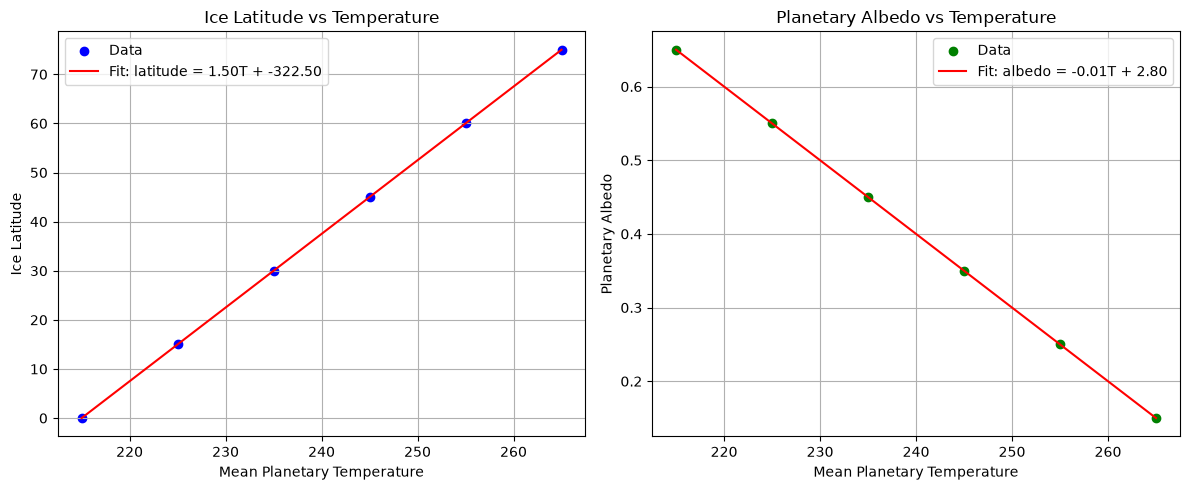

In [51]:

# Set up data arrays
temp_data=np.array([265,255,245,235,225,215])
ice_latitude_data=np.array([75,60,45,30,15,0])
albedo_data=np.array([0.15,0.25,0.35,0.45,0.55,0.65])

# Create a matrix for temperature. The first column is the data, the second column is 1, representing the scale factor for the constant part
A = np.column_stack((temp_data, np.ones_like(temp_data)))

# Use the built-in least squares function to fit the data
m1, b1 = np.linalg.lstsq(A, ice_latitude_data, rcond=None)[0]
m2, b2 = np.linalg.lstsq(A, albedo_data, rcond=None)[0]

print("Ice latitude:")
print("m1 =", m1)
print("b1 =", b1)

print("\nPlanetary albedo:")
print("m2 =", m2)
print("b2 =", b2)

# Smooth temperature values for plotting the lines
temp_line = np.linspace(temp_data.min(), temp_data.max(), 200)

ice_line = m1 * temp_line + b1
albedo = m2 * temp_line + b2

# Create two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ice latitude plot
axes[0].scatter(temp_data, ice_latitude_data, color="blue", label="Data")
axes[0].plot(
    temp_line,
    ice_line,
    color="red",
    label=f"Fit: latitude = {m1:.2f}T + {b1:.2f}"
)
axes[0].set_xlabel("Mean Planetary Temperature")
axes[0].set_ylabel("Ice Latitude")
axes[0].set_title("Ice Latitude vs Temperature")
axes[0].legend()
axes[0].grid(True)

# Albedo plot
axes[1].scatter(temp_data, albedo_data, color="green", label="Data")
axes[1].plot(
    temp_line,
    albedo,
    color="red",
    label=f"Fit: albedo = {m2:.2f}T + {b2:.2f}"
)
axes[1].set_xlabel("Mean Planetary Temperature")
axes[1].set_ylabel("Planetary Albedo")
axes[1].set_title("Planetary Albedo vs Temperature")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Iterating to find a stable temperature
As mentioned above, there can be multiple values of temperature for each given value of solar radiation. Given a system of equations, we can iterate until the values of their variables converge. 
We have the Stefan-Boltzmann law, given as $\frac{L(1-\alpha)}{4}=\epsilon \sigma T^4$, as well as the linear approximation of the data from above, $\alpha = m_2 \times T + b_2$. This gives us our system of equations.

We also need to constrain the values of $\alpha$. Physically, once all of the ice melts, the planet does not get less reflective as it warms. Similarly, once the planet is covered in ice, it does not get more reflective as it cools. The problem tells us to use the range $0.15 < \alpha < 0.65$.

In [ ]:
LRange = [1200, 1600]       # Given by problem statement
albedoRange = [0.15, 0.65]  # Given by problem statement
epsilon = 1                 # Given by problem statement
sigma = 5.67E-8             # W/m2 K4

In [ ]:
max_iterations = 1000   # Prevent the simulation from running forever

In [ ]:
# Derived from Stefan-Boltzmann law
def tempFromAlbedo(L, albedo):
    return pow(L*(1-albedo)/(4*sigma*epsilon), 1/4)

In [ ]:
# Our linear approximation of the data from part 1
def albedoFromTemp(temp):
    return m2*temp + b2

In [ ]:
# Our linear approximation of the data from part 1
def iceLatitudeFromTemp(temp):
    return m1*temp + b1

In [ ]:
# Inner loop to converge the values of temperature and albedo
def albedoTempLoop(L, albedo, max_iterations = max_iterations):
    # Choose a precision value to determine convergance
    precision = 0.01
    old_albedo = albedo
    for _ in range(max_iterations):
        temp = tempFromAlbedo(L, albedo)
        albedo = albedoFromTemp(temp)
        # Hold albedo within the specified range
        albedo = max(min(albedo, albedoRange[1]), albedoRange[0])
        if (old_albedo - precision < albedo < old_albedo + precision):
            # Stability has been reached
            break
        old_albedo = albedo
    # Whether we reached stability or exceeded our number of iterations, we need to return the values
    ice_latitude = iceLatitudeFromTemp(temp)
    return temp, albedo, ice_latitude

Due to the hysteresis, the results reached will differ depending on if we start at the coldest point and go through a warming cycle, or start at the warmest point and go through a cooling cycle. We will go through both scenarios.

In [ ]:
# Create a place to store the results
L_list = [[],[]]
temp_list = [[],[]]
albedo_list = [[],[]]
ice_latitude_list = [[],[]]

# Run the simulation in the cooling direction
L = LRange[1]
albedo_data = albedoRange[0]
while L >= LRange[0]:
    temp, albedo_data, ice_latitude_data = albedoTempLoop(L, albedo_data)
    L_list[0].append(L)
    temp_list[0].append(temp)
    albedo_list[0].append(albedo_data)
    ice_latitude_list[0].append(ice_latitude_data)
    L = L - 10

# Run the simulation in the warming direction
L = LRange[0]
while L <= LRange[1]:
    temp, albedo_data, ice_latitude_data = albedoTempLoop(L, albedo_data)
    L_list[1].append(L)
    temp_list[1].append(temp)
    albedo_list[1].append(albedo_data)
    ice_latitude_list[1].append(ice_latitude_data)
    L = L + 10

Now that we have our results, we can plot the data. The first chart will be L vs Temperature. We will plot both the warming cycle data and the cooling cycle data on the same plot to show the hysteresis.

[]

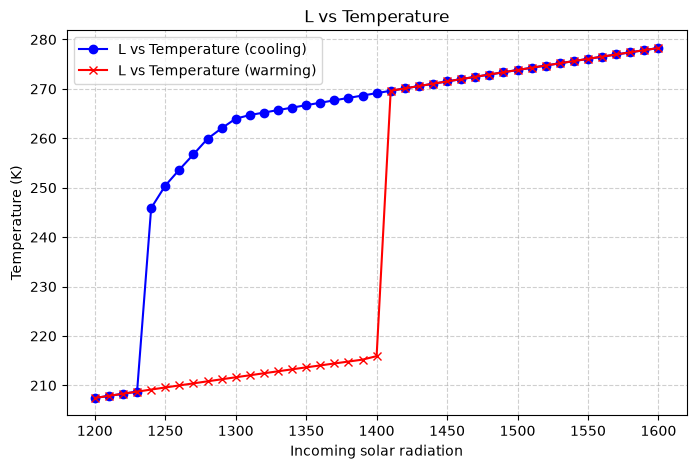

In [54]:
# Hysteresis loop
plt.figure(figsize=(8,5))
plt.plot(L_list[0], temp_list[0], marker='o', linestyle='-', color='b', label='L vs Temperature (cooling)')
plt.plot(L_list[1], temp_list[1], marker='x', linestyle='-', color='r', label='L vs Temperature (warming)')

plt.title("L vs Temperature")
plt.xlabel('Incoming solar radiation')
plt.ylabel('Temperature (K)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.plot()

We can also see the hysteresis in the plots of albedo and of ice latitude. 

[]

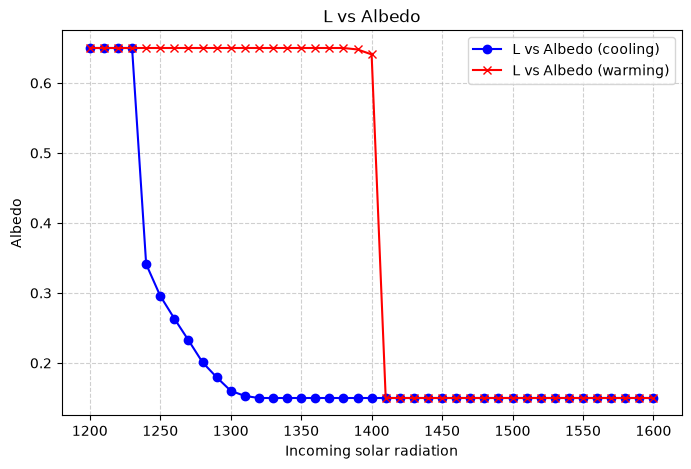

In [39]:
# Albedo
plt.figure(figsize=(8,5))
plt.plot(L_list[0], albedo_list[0], marker='o', linestyle='-', color='b', label='L vs Albedo (cooling)')
plt.plot(L_list[1], albedo_list[1], marker='x', linestyle='-', color='r', label='L vs Albedo (warming)')

plt.title("L vs Albedo")
plt.xlabel('Incoming solar radiation')
plt.ylabel('Albedo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.plot()

The ice latitude plot shows ice below 0 degrees and above 90 degrees, which is not possible. This is a consequence of constraining the simulation based on arbitrary values of albedo. A more accurate simulation would constrain the ice latitude to between 0 and 90 degrees, and choose albedo constraints based on that.

[]

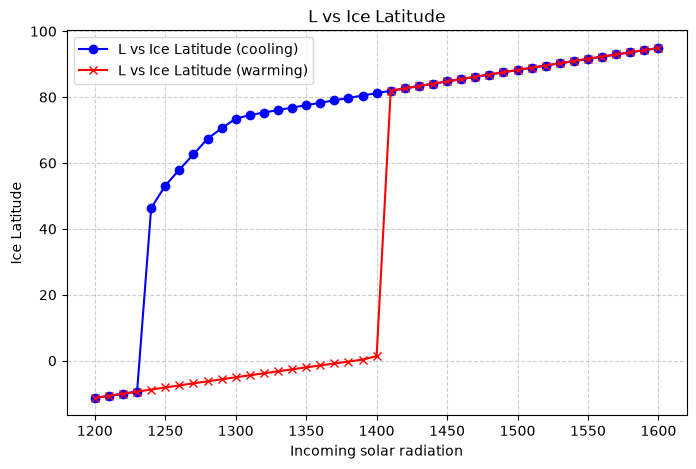

In [40]:
# Ice Latitude
plt.figure(figsize=(8,5))
plt.plot(L_list[0], ice_latitude_list[0], marker='o', linestyle='-', color='b', label='L vs Ice Latitude (cooling)')
plt.plot(L_list[1], ice_latitude_list[1], marker='x', linestyle='-', color='r', label='L vs Ice Latitude (warming)')

plt.title("L vs Ice Latitude")
plt.xlabel('Incoming solar radiation')
plt.ylabel('Ice Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.plot()

The problem asks us to also plot temperature vs iteration number. This clearly shows the runaway effect, with gradual changes giving way to a stark jump at the inflection point. The fact that the inflection points differ depending on whether we are warming or cooling gives us the hysteresis effect.

[]

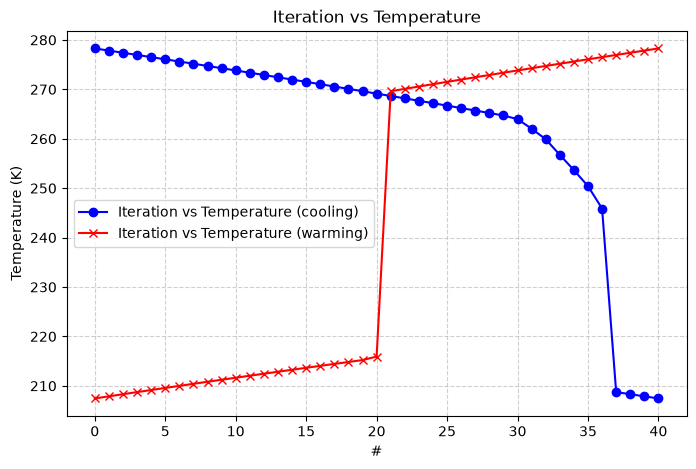

In [43]:
# Temperature vs Iteration
plt.figure(figsize=(8,5))
plt.plot(range(len(temp_list[0])), temp_list[0], marker='o', linestyle='-', color='b', label='Iteration vs Temperature (cooling)')
plt.plot(range(len(temp_list[1])), temp_list[1], marker='x', linestyle='-', color='r', label='Iteration vs Temperature (warming)')

plt.title("Iteration vs Temperature")
plt.xlabel('#')
plt.ylabel('Temperature (K)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.plot()